OBJECTIVE: use machine learning to create a model that predicts which passengers survived the Titanic shipwreck.

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pandas.plotting import scatter_matrix

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve


In [2]:
# Import training set
df = pd.read_csv("/Users/alinemitri/Documents/Machine Learning/hands-on-ML-book/datasets/titanic/train.csv")

In [3]:
# Verify first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Verify columns' types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Observations
- 7 numerical features
- 5 categorical features
- Survived is the label: 0 = no, 1 = yes
- Name is irrelevant
- Sex can be changed to numerical variable
- Age has 19.9% of missing values
- SibSp means number of siblings/spouses aboard the Titanic
- Parch maeans number of parents/children aboard the Titanic
- Ticket number seems irrelevant
- Cabin has 77% of missing values
- Embarked has 2 missing values; C = Cherbourg, Q = Queenstown, S = Southampton

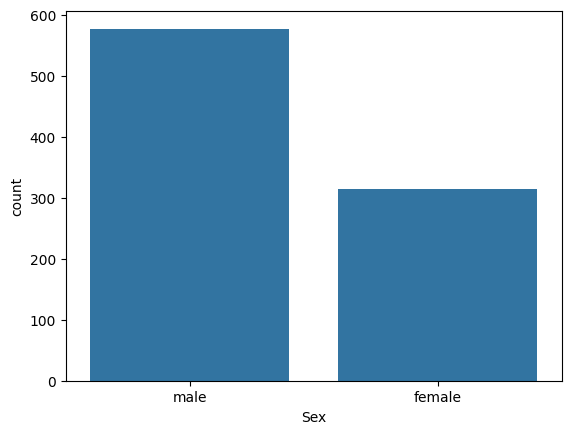

In [5]:
# Verify sex information
sns.countplot(data=df, x="Sex")
plt.show()

In [6]:
# Transform sex categories to numerical values
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


How to deal with missing values in Age?
- Compute the median of male and female ages
- Change missing values to the median age, according to the sex of the person.

In [8]:
# Compute median
medians = df.groupby("Sex")["Age"].median()
print(medians)

Sex
0    29.0
1    27.0
Name: Age, dtype: float64


In [9]:
# Compute mean
means = df.groupby("Sex")["Age"].mean()
print(means)

Sex
0    30.726637
1    27.915709
Name: Age, dtype: float64


In [10]:
# Change missing values to the median age
df["Age"] = df.groupby("Sex")["Age"].transform(lambda x: x.fillna(x.median()))

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [12]:
# Modify Embarked to numerical categories
embarked_classes= [
    df['Embarked'].isna(),
    df['Embarked'] == 'C',
    df['Embarked'] == 'Q',
    df['Embarked'] == 'S',
]

embarked_values = [0, 1, 2, 3]

df['Embarked'] = np.select(embarked_classes, embarked_values)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 83.7+ KB


In [14]:
# Drop categorical features
categorical_features = [
    "Name",
    "Ticket",
    "Cabin",
]

df_train = df.drop(categorical_features, axis=1)

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


In [16]:
# Verify distribution of features according to labels
numerical_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
]

for var in numerical_features:
    print(var)
    print(df_train.groupby("Survived")[var].describe().round(2))

Pclass
          count  mean   std  min  25%  50%  75%  max
Survived                                            
0         549.0  2.53  0.74  1.0  2.0  3.0  3.0  3.0
1         342.0  1.95  0.86  1.0  1.0  2.0  3.0  3.0
Sex
          count  mean   std  min  25%  50%  75%  max
Survived                                            
0         549.0  0.15  0.35  0.0  0.0  0.0  0.0  1.0
1         342.0  0.68  0.47  0.0  0.0  1.0  1.0  1.0
Age
          count   mean    std   min   25%   50%   75%   max
Survived                                                   
0         549.0  30.19  12.48  1.00  23.0  29.0  35.0  74.0
1         342.0  28.23  13.77  0.42  21.0  27.0  35.0  80.0
SibSp
          count  mean   std  min  25%  50%  75%  max
Survived                                            
0         549.0  0.55  1.29  0.0  0.0  0.0  1.0  8.0
1         342.0  0.47  0.71  0.0  0.0  0.0  1.0  4.0
Parch
          count  mean   std  min  25%  50%  75%  max
Survived                                    

array([[<Axes: xlabel='Pclass', ylabel='Pclass'>,
        <Axes: xlabel='Sex', ylabel='Pclass'>,
        <Axes: xlabel='Age', ylabel='Pclass'>,
        <Axes: xlabel='SibSp', ylabel='Pclass'>,
        <Axes: xlabel='Parch', ylabel='Pclass'>,
        <Axes: xlabel='Fare', ylabel='Pclass'>,
        <Axes: xlabel='Embarked', ylabel='Pclass'>],
       [<Axes: xlabel='Pclass', ylabel='Sex'>,
        <Axes: xlabel='Sex', ylabel='Sex'>,
        <Axes: xlabel='Age', ylabel='Sex'>,
        <Axes: xlabel='SibSp', ylabel='Sex'>,
        <Axes: xlabel='Parch', ylabel='Sex'>,
        <Axes: xlabel='Fare', ylabel='Sex'>,
        <Axes: xlabel='Embarked', ylabel='Sex'>],
       [<Axes: xlabel='Pclass', ylabel='Age'>,
        <Axes: xlabel='Sex', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='SibSp', ylabel='Age'>,
        <Axes: xlabel='Parch', ylabel='Age'>,
        <Axes: xlabel='Fare', ylabel='Age'>,
        <Axes: xlabel='Embarked', ylabel='Age'>],
       [<Axes

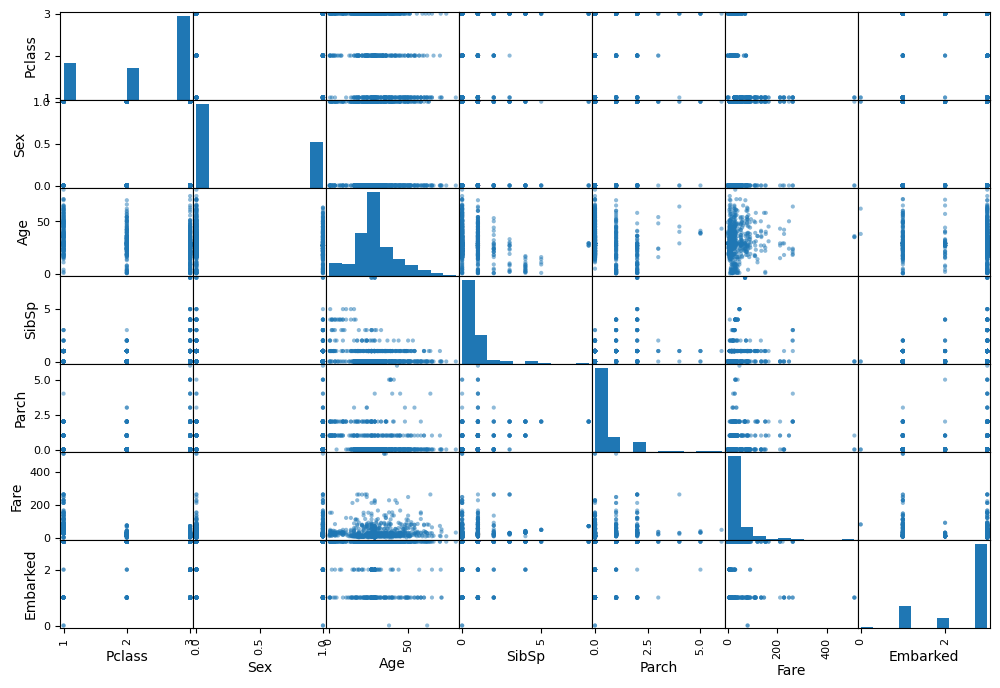

In [17]:
# Check for correlation with scatter_matrix 
scatter_matrix(df_train[numerical_features], figsize=(12,8))

Machine Learning Models

In [18]:
# Create training set and label
y_train = df_train["Survived"].copy()
X_train = df_train.drop("Survived", axis=1)

SGD Classifier

In [19]:
# Create the Stochastic Gradient Descent (SGD) classifier
sgd_clf = SGDClassifier(random_state=42, n_jobs=-1)
sgd_clf.fit(X_train, y_train)

SGDClassifier(n_jobs=-1, random_state=42)

In [20]:
#Measure accuracy using cross-validation
cross_val_score(sgd_clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

array([0.59776536, 0.64606742, 0.60674157, 0.61797753, 0.61797753])

In [21]:
#Transform the attributes to have the same scale
standard_scaler = StandardScaler()

X_train =standard_scaler.fit_transform(X_train)

In [22]:
sgd_clf.fit(X_train, y_train)

SGDClassifier(n_jobs=-1, random_state=42)

In [23]:
cross_val_score(sgd_clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

array([0.69273743, 0.67977528, 0.78651685, 0.75842697, 0.78651685])

In [24]:
#Threshold selection
y_scores = cross_val_predict(sgd_clf, X_train, y_train, cv=5, method='decision_function')

In [25]:
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

In [26]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.legend(loc="center right", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)                             
    #plt.axis([-50000, 50000, 0, 1])

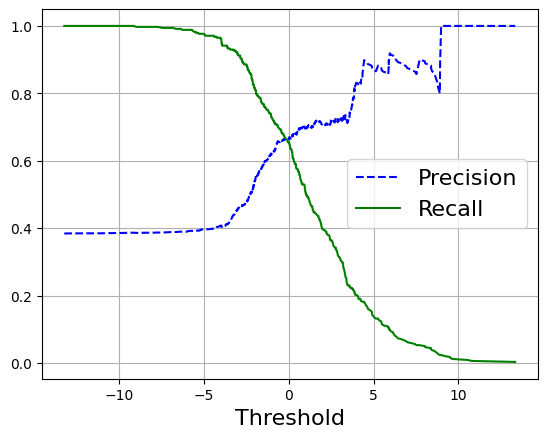

In [27]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [28]:
# Find the first argument that gives 90% of precision
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
threshold_90_precision

np.float64(5.96016322707689)

In [29]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, y_scores)

In [30]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') #dashed diagonal
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.grid(True)

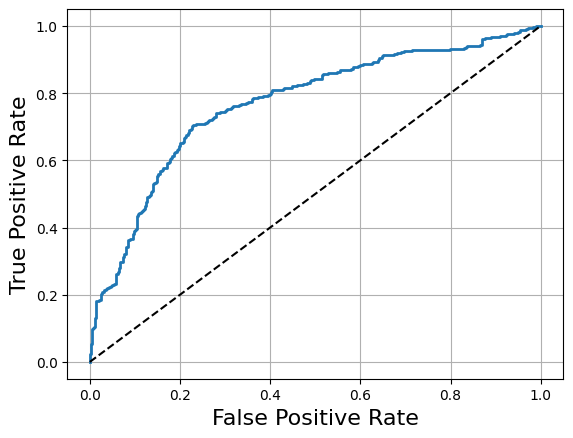

In [31]:
plot_roc_curve(fpr, tpr)
plt.show()

In [32]:
#Area under the curve (AUC)
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train, y_scores)

np.float64(0.7700231148606184)

In [44]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=5, n_jobs=-1)

In [45]:
from sklearn.metrics import confusion_matrix
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

array([[436, 113],
       [118, 224]])

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision_score(y_train, y_train_pred)

0.6646884272997032

In [47]:
recall_score(y_train, y_train_pred)

0.6549707602339181

In [48]:
f1_score(y_train, y_train_pred)

0.6597938144329897

In [65]:
accuracy_score(y_train, y_train_pred)

0.7407407407407407

Random Forest Classifier

In [33]:
# Create a Random Forest classifier
forest_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
forest_clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [34]:
cross_val_score(forest_clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

array([0.70391061, 0.80337079, 0.83707865, 0.80898876, 0.83146067])

In [35]:
y_prob_forest = cross_val_predict(forest_clf, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)

In [36]:
y_scores_forest = y_prob_forest[:,1]

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

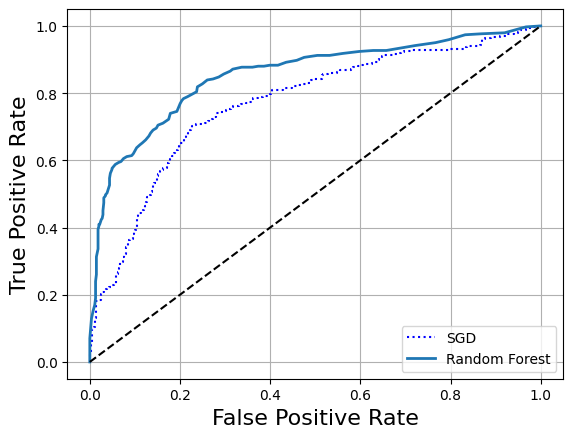

In [37]:
plt.plot(fpr, tpr, 'b:', label='SGD')
plot_roc_curve(fpr_forest, tpr_forest, 'Random Forest')
plt.legend(loc='lower right')
plt.show()

In [38]:
roc_auc_score(y_train, y_scores_forest)

np.float64(0.853484272307971)

In [55]:
y_pred_fc = cross_val_predict(forest_clf, X_train, y_train, cv=3, n_jobs=-1)
confusion_matrix(y_train, y_pred_fc)

array([[480,  69],
       [103, 239]])

In [66]:
accuracy_score(y_train, y_pred_fc)

0.8069584736251403

In [56]:
precision_score(y_train, y_pred_fc)

0.775974025974026

In [57]:
recall_score(y_train, y_pred_fc)

0.6988304093567251

In [58]:
f1_score(y_train, y_pred_fc)

0.7353846153846154

In [39]:
#Fine-tune Random Forest Model with Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_estimators": [50, 125, 250, 500]},
    {"bootstrap": [False], "n_estimators": [125, 250, 500]},
]

grid_search = GridSearchCV(forest_clf, param_grid, cv=5,
                           scoring="accuracy",
                           return_train_score=True,
                           n_jobs=-1
                           )

grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid=[{'n_estimators': [50, 125, 250, 500]},
                         {'bootstrap': [False],
                          'n_estimators': [125, 250, 500]}],
             return_train_score=True, scoring='accuracy')

In [40]:
forest_clf_better = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
forest_clf_better.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [41]:
cross_val_score(forest_clf_better, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)

array([0.73184358, 0.80337079, 0.84831461, 0.80898876, 0.83707865])

In [59]:
y_pred_fcb = cross_val_predict(forest_clf_better, X_train, y_train, cv=3, n_jobs=-1)
confusion_matrix(y_train, y_pred_fcb)

array([[481,  68],
       [ 99, 243]])

In [67]:
accuracy_score(y_train, y_pred_fcb)

0.8125701459034792

In [60]:
precision_score(y_train, y_pred_fcb)

0.7813504823151125

In [61]:
recall_score(y_train, y_pred_fcb)

0.7105263157894737

In [62]:
f1_score(y_train, y_pred_fcb)

0.7442572741194488

In [75]:
y_prob_fcb = cross_val_predict(forest_clf_better, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)
y_scores_fcb= y_prob_fcb[:,1]

fpr_fcb, tpr_fcb, thresholds_fcb = roc_curve(y_train, y_scores_fcb)

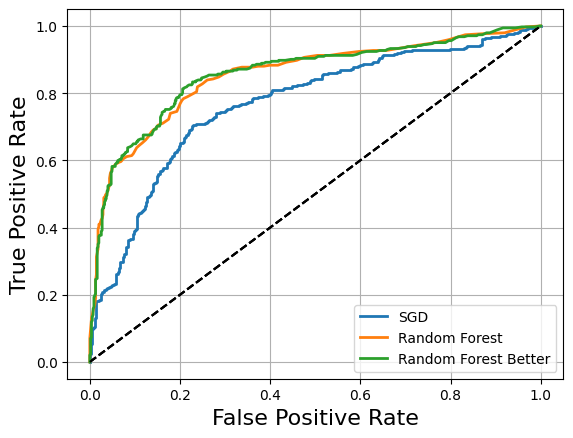

In [76]:
plot_roc_curve(fpr, tpr, 'SGD')
plot_roc_curve(fpr_forest, tpr_forest, 'Random Forest')
plot_roc_curve(fpr_fcb, tpr_fcb, 'Random Forest Better')
plt.legend(loc='lower right')
plt.show()

Support Vector Machine

In [78]:
from sklearn import svm

svm_clf = svm.SVC()
svm_clf.fit(X_train, y_train)

SVC()

In [79]:
y_pred_svm = cross_val_predict(svm_clf, X_train, y_train, cv=5, n_jobs=-1)
confusion_matrix(y_train, y_pred_svm)

array([[496,  53],
       [105, 237]])

In [80]:
accuracy_score(y_train, y_pred_svm)

0.8226711560044894

In [81]:
precision_score(y_train, y_pred_svm)

0.8172413793103448

In [83]:
recall_score(y_train, y_pred_svm)

0.6929824561403509

In [84]:
f1_score(y_train, y_pred_svm)

0.75

In [86]:
y_scores_svm = cross_val_predict(svm_clf, X_train, y_train, cv=5, method='decision_function', n_jobs=-1)

In [87]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_train, y_scores_svm)

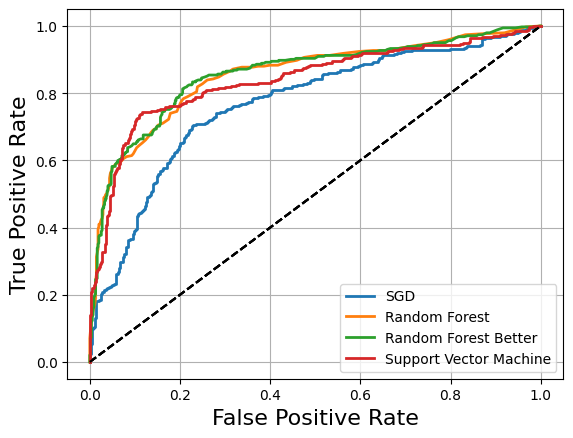

In [88]:
plot_roc_curve(fpr, tpr, 'SGD')
plot_roc_curve(fpr_forest, tpr_forest, 'Random Forest')
plot_roc_curve(fpr_fcb, tpr_fcb, 'Random Forest Better')
plot_roc_curve(fpr_svm, tpr_svm, 'Support Vector Machine')
plt.legend(loc='lower right')
plt.show()